# English-to-Spanish translation with a sequence-to-sequence Transformer

**Credits:** This code is adapted from https://keras.io/examples/nlp/neural_machine_translation_with_transformer/
and extended with hyperparameter tuning (KerasTuner) and proper translation-quality evaluation.

### Changes from the keras.io example

- **Metrics:** training reports a *masked* token accuracy that ignores padding. Plain `accuracy`
  counts the padded positions (~65% of each target), so it could never exceed ~0.35.
  Tuning and early stopping use `val_loss`.
- **Evaluation:** corpus BLEU and chrF on held-out test sentences, with greedy and beam-search decoding.
- **Model:** stacked encoder/decoder layers, dropout inside attention and on residual branches,
  and AdamW with warmup and inverse-square-root decay.
- **Tuning:** Hyperband over depth, width, dropout, learning rate and weight decay, with early
  stopping. The final model is retrained from scratch using the best hyperparameters.
- **Data:** Unicode-aware lowercasing, `¡` stripping, and a train/val/test split by English
  sentence, so no test source sentence is seen during training.
- **Reproducibility:** a fixed seed, and the model and vocabularies are saved for later reuse.

## Introduction

In this example, we'll build a sequence-to-sequence Transformer model, which
we'll train on an English-to-Spanish machine translation task.

You'll learn how to:

- Vectorize text using the Keras `TextVectorization` layer.
- Implement a `TransformerEncoder` layer, a `TransformerDecoder` layer,
and a `PositionalEmbedding` layer.
- Prepare data for training a sequence-to-sequence model.
- Tune the model's hyperparameters with KerasTuner's Hyperband.
- Use the trained model to generate translations of never-seen-before
input sentences (sequence-to-sequence inference), with greedy and beam-search decoding.
- Measure translation quality with BLEU and chrF.

The code featured here is adapted from the book
[Deep Learning with Python, Second Edition](https://www.manning.com/books/deep-learning-with-python-second-edition)
(chapter 11: Deep learning for text).
The present example is fairly barebones, so for detailed explanations of
how each building block works, as well as the theory behind Transformers,
I recommend reading the book.

## Setup

[`sacrebleu`](https://github.com/mjpost/sacrebleu) computes BLEU and chrF scores.

In [1]:
%pip install -q sacrebleu keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 12.0 MB/s eta 0:00:00


In [2]:
import os

# The code works with the `tensorflow` and `torch` backends. To use another backend,
# set KERAS_BACKEND before starting the kernel.
os.environ.setdefault("KERAS_BACKEND", "tensorflow")

import json
import pathlib
import random
import re
import string
from collections import defaultdict

import keras
import keras_tuner as kt
import matplotlib.pyplot as plt
import numpy as np
import sacrebleu
import tensorflow as tf
import tensorflow.data as tf_data
import tensorflow.strings as tf_strings
from keras import layers, ops
from keras.layers import TextVectorization

All tunable settings live in this one cell. For a quick end-to-end check, set `max_pairs` to
something like `20_000` and lower the epoch counts.

In [3]:
seed = 42

# Data and vectorization
vocab_size = 15000
sequence_length = 20
batch_size = 64
max_pairs = None  # e.g. 20_000 for a quick run; None uses the full dataset

# Hyperparameter search (Hyperband). With tune_max_epochs=10 and tune_factor=3, the search
# trains 22 configurations for ~120 epochs in total (less with early stopping).
tune_max_epochs = 10
tune_factor = 3
tuner_dir = "tuning"
tuner_project = "english-spanish-translation"

# Final training
final_max_epochs = 50  # upper bound; early stopping usually ends training much sooner
early_stopping_patience = 3
warmup_steps = 1000
activation = "gelu"
artifacts_dir = pathlib.Path("artifacts")

# Evaluation
max_eval_sentences = 3000  # test sentences scored with BLEU/chrF; None scores the whole test set
beam_width = 4

keras.utils.set_random_seed(seed)

Check which accelerator Keras will use. This model is small, but the full hyperparameter
search is still many hours of work on a CPU, so it's worth confirming a GPU is visible first.

In [4]:
backend = keras.backend.backend()
if backend == "tensorflow":
    accelerators = tf.config.list_physical_devices("GPU")
elif backend == "torch":
    import torch

    accelerators = [
        name
        for name, available in [
            ("cuda", torch.cuda.is_available()),
            ("mps", torch.backends.mps.is_available()),
        ]
        if available
    ]
else:
    import jax

    accelerators = [d for d in jax.devices() if d.platform != "cpu"]

print(f"Keras backend: {backend}")
print(f"Accelerators: {accelerators or 'none'}")
if not accelerators:
    print(
        "WARNING: no GPU is visible, so training will run on the CPU and the full search "
        "will take a day or more. Use a GPU runtime (e.g. Colab's T4), or reduce max_pairs "
        "and the epoch budgets above."
    )

Keras backend: tensorflow
Accelerators: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Downloading the data

We'll be working with an English-to-Spanish translation dataset
provided by [Anki](https://www.manythings.org/anki/). Let's download it:

In [5]:
download_path = pathlib.Path(
    keras.utils.get_file(
        fname="spa-eng.zip",
        origin="http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip",
        extract=True,
    )
)
# Newer Keras versions return the extraction directory; older ones return the zip file's path.
text_file = next(
    path
    for path in [
        download_path / "spa-eng" / "spa.txt",
        download_path.parent / "spa-eng" / "spa.txt",
    ]
    if path.exists()
)
print(text_file)

2638744/2638744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
/root/.keras/datasets/spa-eng_extracted/spa-eng/spa.txt


## Parsing the data

Each line contains an English sentence and its corresponding Spanish sentence.
The English sentence is the *source sequence* and Spanish one is the *target sequence*.
We prepend the token `"[start]"` and we append the token `"[end]"` to the Spanish sentence.

In [6]:
with open(text_file, encoding="utf-8") as f:
    lines = f.read().split("\n")[:-1]
text_pairs = []
for line in lines:
    eng, spa = line.split("\t")
    spa = "[start] " + spa + " [end]"
    text_pairs.append((eng, spa))

if max_pairs is not None:
    text_pairs = random.Random(seed).sample(text_pairs, max_pairs)

Here's what our sentence pairs look like:

In [7]:
for pair in random.Random(seed).sample(text_pairs, 5):
    print(pair)

('There is no doubt about his ability.', '[start] No hay ninguna duda sobre su habilidad. [end]')
('They were amazing.', '[start] Fueron maravillosos. [end]')
("That'll last.", '[start] Durará. [end]')
('I spent the holidays decorating the house.', '[start] Pasé las vacaciones decorando la casa. [end]')
('I have the ace of clubs.', '[start] Tengo el as de tréboles. [end]')


Now, let's split the sentence pairs into a training set, a validation set,
and a test set.

Many English sentences appear several times with different Spanish translations. Splitting
individual pairs at random would put ~18% of the test set's English sentences in the
training set too, which inflates test scores. So we split by *English sentence*: every
translation of a given sentence lands in the same set. The shuffle is seeded, so re-running
the notebook reproduces the same split.

In [8]:
sources = sorted({eng for eng, _ in text_pairs})
random.Random(seed).shuffle(sources)
num_val_sources = int(0.15 * len(sources))
val_sources = set(sources[:num_val_sources])
test_sources = set(sources[num_val_sources : 2 * num_val_sources])

train_pairs = [p for p in text_pairs if p[0] not in val_sources and p[0] not in test_sources]
val_pairs = [p for p in text_pairs if p[0] in val_sources]
test_pairs = [p for p in text_pairs if p[0] in test_sources]

train_sources = {eng for eng, _ in train_pairs}
assert not train_sources & val_sources and not train_sources & test_sources

print(f"{len(text_pairs)} total pairs ({len(sources)} distinct English sentences)")
print(f"{len(train_pairs)} training pairs")
print(f"{len(val_pairs)} validation pairs")
print(f"{len(test_pairs)} test pairs")

118964 total pairs (102904 distinct English sentences)
83245 training pairs
17917 validation pairs
17802 test pairs


## Vectorizing the text data

We'll use two instances of the `TextVectorization` layer to vectorize the text
data (one for English and one for Spanish),
that is to say, to turn the original strings into integer sequences
where each integer represents the index of a word in a vocabulary.

Both layers use the same custom standardization: lowercase the text, then strip punctuation,
including the Spanish `"¿"` and `"¡"`. The lowercasing must be Unicode-aware
(`encoding="utf-8"`). By default `tf.strings.lower` only lowercases ASCII, which would make
"Él" and "él" different tokens.

Note: in a production-grade machine translation model, I would not recommend
stripping the punctuation characters in either language. Instead, I would recommend turning
each punctuation character into its own token,
which you could achieve by providing a custom `split` function to the `TextVectorization` layer.

In [9]:
strip_chars = string.punctuation + "¿¡"
strip_chars = strip_chars.replace("[", "")
strip_chars = strip_chars.replace("]", "")


def custom_standardization(input_string):
    lowercase = tf_strings.lower(input_string, encoding="utf-8")
    return tf_strings.regex_replace(lowercase, "[%s]" % re.escape(strip_chars), "")


eng_vectorization = TextVectorization(
    max_tokens=vocab_size,
    output_mode="int",
    output_sequence_length=sequence_length,
    standardize=custom_standardization,
)
spa_vectorization = TextVectorization(
    max_tokens=vocab_size,
    output_mode="int",
    output_sequence_length=sequence_length + 1,
    standardize=custom_standardization,
)
train_eng_texts = [pair[0] for pair in train_pairs]
train_spa_texts = [pair[1] for pair in train_pairs]
eng_vectorization.adapt(train_eng_texts)
spa_vectorization.adapt(train_spa_texts)

Next, we'll format our datasets.

At each training step, the model will seek to predict target words N+1 (and beyond)
using the source sentence and the target words 0 to N.

As such, the training dataset will yield a tuple `(inputs, targets)`, where:

- `inputs` is a dictionary with the keys `encoder_inputs` and `decoder_inputs`.
`encoder_inputs` is the vectorized source sentence and `decoder_inputs` is the target sentence "so far",
that is to say, the words 0 to N used to predict word N+1 (and beyond) in the target sentence.
- `target` is the target sentence offset by one step:
it provides the next words in the target sentence -- what the model will try to predict.

Each split is vectorized once up front. The training set is shuffled one pair at a time and
reshuffled every epoch, so batches are different each epoch.

In [10]:
def make_dataset(pairs, shuffle=False):
    eng_texts, spa_texts = zip(*pairs)
    eng = ops.convert_to_numpy(eng_vectorization(list(eng_texts)))
    spa = ops.convert_to_numpy(spa_vectorization(list(spa_texts)))
    dataset = tf_data.Dataset.from_tensor_slices(
        (
            {
                "encoder_inputs": eng,
                "decoder_inputs": spa[:, :-1],
            },
            spa[:, 1:],
        )
    )
    if shuffle:
        dataset = dataset.shuffle(len(pairs), seed=seed)
    return dataset.batch(batch_size).prefetch(tf_data.AUTOTUNE)


train_ds = make_dataset(train_pairs, shuffle=True)
val_ds = make_dataset(val_pairs)
test_ds = make_dataset(test_pairs)

Let's take a quick look at the sequence shapes
(we have batches of 64 pairs, and all sequences are 20 steps long):

In [11]:
for inputs, targets in train_ds.take(1):
    print(f'inputs["encoder_inputs"].shape: {inputs["encoder_inputs"].shape}')
    print(f'inputs["decoder_inputs"].shape: {inputs["decoder_inputs"].shape}')
    print(f"targets.shape: {targets.shape}")

inputs["encoder_inputs"].shape: (64, 20)
inputs["decoder_inputs"].shape: (64, 20)
targets.shape: (64, 20)


## Building the model

Our sequence-to-sequence Transformer consists of a stack of `TransformerEncoder` layers
and a stack of `TransformerDecoder` layers. To make the model aware of word order,
we also use a `PositionalEmbedding` layer.

The source sequence will be passed to the encoder stack,
which will produce a new representation of it.
This new representation will then be passed
to the decoder stack, together with the target sequence so far (target words 0 to N).
The decoder will then seek to predict the next words in the target sequence (N+1 and beyond).

A key detail that makes this possible is causal masking
(`use_causal_mask=True` in the decoder's self-attention).
The decoder sees the entire sequences at once, and thus we must make
sure that it only uses information from target tokens 0 to N when predicting token N+1
(otherwise, it could use information from the future, which would
result in a model that cannot be used at inference time).

Padding masks are passed to the attention layers explicitly. Dropout is applied to the
embeddings, inside attention, and on each residual branch, since the original single-layer
model overfit heavily.

The layers are defined at module level and registered with Keras, so a saved model can be
loaded outside this notebook.

In [12]:
@keras.saving.register_keras_serializable(package="nmt")
class PaddingMask(layers.Layer):
    # True for real tokens, False for padding (token id 0).
    def call(self, token_ids):
        return ops.not_equal(token_ids, 0)


@keras.saving.register_keras_serializable(package="nmt")
class PositionalEmbedding(layers.Layer):
    def __init__(self, sequence_length, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_embeddings = layers.Embedding(
            input_dim=vocab_size, output_dim=embed_dim
        )
        self.position_embeddings = layers.Embedding(
            input_dim=sequence_length, output_dim=embed_dim
        )
        self.sequence_length = sequence_length
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim

    def build(self, input_shape):
        self.token_embeddings.build(input_shape)
        self.position_embeddings.build(input_shape)

    def call(self, inputs):
        length = ops.shape(inputs)[-1]
        positions = ops.arange(0, length, 1)
        embedded_tokens = self.token_embeddings(inputs)
        embedded_positions = self.position_embeddings(positions)
        return embedded_tokens + embedded_positions

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "sequence_length": self.sequence_length,
                "vocab_size": self.vocab_size,
                "embed_dim": self.embed_dim,
            }
        )
        return config


@keras.saving.register_keras_serializable(package="nmt")
class TransformerEncoder(layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, dropout, activation, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads
        self.dropout = dropout
        self.activation = activation
        self.attention = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim // num_heads, dropout=dropout
        )
        self.dense_proj = keras.Sequential(
            [
                layers.Dense(dense_dim, activation=activation),
                layers.Dense(embed_dim),
            ]
        )
        self.dropout_1 = layers.Dropout(dropout)
        self.dropout_2 = layers.Dropout(dropout)
        self.layernorm_1 = layers.LayerNormalization()
        self.layernorm_2 = layers.LayerNormalization()

    def build(self, input_shape):
        self.attention.build(input_shape, input_shape)
        self.dense_proj.build(input_shape)
        self.layernorm_1.build(input_shape)
        self.layernorm_2.build(input_shape)

    def call(self, inputs, padding_mask=None, training=None):
        attention_output = self.attention(
            query=inputs, value=inputs, key=inputs, value_mask=padding_mask, training=training
        )
        proj_input = self.layernorm_1(inputs + self.dropout_1(attention_output, training=training))
        proj_output = self.dense_proj(proj_input)
        return self.layernorm_2(proj_input + self.dropout_2(proj_output, training=training))

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "embed_dim": self.embed_dim,
                "dense_dim": self.dense_dim,
                "num_heads": self.num_heads,
                "dropout": self.dropout,
                "activation": self.activation,
            }
        )
        return config


@keras.saving.register_keras_serializable(package="nmt")
class TransformerDecoder(layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, dropout, activation, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads
        self.dropout = dropout
        self.activation = activation
        self.attention_1 = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim // num_heads, dropout=dropout
        )
        self.attention_2 = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim // num_heads, dropout=dropout
        )
        self.dense_proj = keras.Sequential(
            [
                layers.Dense(dense_dim, activation=activation),
                layers.Dense(embed_dim),
            ]
        )
        self.dropout_1 = layers.Dropout(dropout)
        self.dropout_2 = layers.Dropout(dropout)
        self.dropout_3 = layers.Dropout(dropout)
        self.layernorm_1 = layers.LayerNormalization()
        self.layernorm_2 = layers.LayerNormalization()
        self.layernorm_3 = layers.LayerNormalization()

    def build(self, inputs_shape, encoder_outputs_shape):
        self.attention_1.build(inputs_shape, inputs_shape)
        self.attention_2.build(inputs_shape, encoder_outputs_shape)
        self.dense_proj.build(inputs_shape)
        self.layernorm_1.build(inputs_shape)
        self.layernorm_2.build(inputs_shape)
        self.layernorm_3.build(inputs_shape)

    def call(
        self,
        inputs,
        encoder_outputs,
        padding_mask=None,
        encoder_padding_mask=None,
        training=None,
    ):
        attention_output_1 = self.attention_1(
            query=inputs,
            value=inputs,
            key=inputs,
            value_mask=padding_mask,
            use_causal_mask=True,
            training=training,
        )
        out_1 = self.layernorm_1(inputs + self.dropout_1(attention_output_1, training=training))

        attention_output_2 = self.attention_2(
            query=out_1,
            value=encoder_outputs,
            key=encoder_outputs,
            value_mask=encoder_padding_mask,
            training=training,
        )
        out_2 = self.layernorm_2(out_1 + self.dropout_2(attention_output_2, training=training))

        proj_output = self.dense_proj(out_2)
        return self.layernorm_3(out_2 + self.dropout_3(proj_output, training=training))

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "embed_dim": self.embed_dim,
                "dense_dim": self.dense_dim,
                "num_heads": self.num_heads,
                "dropout": self.dropout,
                "activation": self.activation,
            }
        )
        return config

The encoder and decoder are separate sub-models (named `"encoder"` and `"decoder"`), so at
inference time we can encode each source sentence once and then run only the decoder for each
generated token. The final projection onto the Spanish vocabulary is a separate
`"output_projection"` layer for the same reason: during decoding we only need it at one position.

In [13]:
def build_transformer(num_layers, embed_dim, dense_dim, num_heads, dropout):
    encoder_inputs = keras.Input(shape=(None,), dtype="int64", name="encoder_inputs")
    x = PositionalEmbedding(sequence_length, vocab_size, embed_dim)(encoder_inputs)
    x = layers.Dropout(dropout)(x)
    encoder_padding_mask = PaddingMask()(encoder_inputs)
    for _ in range(num_layers):
        x = TransformerEncoder(embed_dim, dense_dim, num_heads, dropout, activation)(
            x, padding_mask=encoder_padding_mask
        )
    encoder = keras.Model(encoder_inputs, x, name="encoder")

    decoder_inputs = keras.Input(shape=(None,), dtype="int64", name="decoder_inputs")
    encoded_seq_inputs = keras.Input(shape=(None, embed_dim), name="encoder_outputs")
    encoder_mask_inputs = keras.Input(shape=(None,), dtype="bool", name="encoder_padding_mask")
    x = PositionalEmbedding(sequence_length, vocab_size, embed_dim)(decoder_inputs)
    x = layers.Dropout(dropout)(x)
    decoder_padding_mask = PaddingMask()(decoder_inputs)
    for _ in range(num_layers):
        x = TransformerDecoder(embed_dim, dense_dim, num_heads, dropout, activation)(
            x,
            encoded_seq_inputs,
            padding_mask=decoder_padding_mask,
            encoder_padding_mask=encoder_mask_inputs,
        )
    decoder = keras.Model(
        {
            "decoder_inputs": decoder_inputs,
            "encoder_outputs": encoded_seq_inputs,
            "encoder_padding_mask": encoder_mask_inputs,
        },
        x,
        name="decoder",
    )

    decoder_hidden = decoder(
        {
            "decoder_inputs": decoder_inputs,
            "encoder_outputs": encoder(encoder_inputs),
            "encoder_padding_mask": PaddingMask()(encoder_inputs),
        }
    )
    x = layers.Dropout(dropout)(decoder_hidden)
    decoder_outputs = layers.Dense(vocab_size, activation="softmax", name="output_projection")(x)
    return keras.Model(
        {"encoder_inputs": encoder_inputs, "decoder_inputs": decoder_inputs},
        decoder_outputs,
        name="transformer",
    )

### Loss, metric and optimizer

- The loss ignores padding (`ignore_class=0`), and so does `MaskedAccuracy`: it scores only
  real target tokens, so it can actually reach 1.0.
- `AdamW` uses a linear warmup followed by inverse-square-root decay (as in *Attention Is All
  You Need*). The schedule doesn't depend on the total number of training steps, so it works
  with early stopping. Biases and layer-norm parameters are excluded from weight decay.

In [14]:
@keras.saving.register_keras_serializable(package="nmt")
class MaskedAccuracy(keras.metrics.Metric):
    # Token-level accuracy over non-padding target positions.
    def __init__(self, name="masked_accuracy", **kwargs):
        super().__init__(name=name, **kwargs)
        self.correct = self.add_variable(shape=(), initializer="zeros", name="correct")
        self.total = self.add_variable(shape=(), initializer="zeros", name="total")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = ops.cast(y_true, "int32")
        mask = ops.not_equal(y_true, 0)
        predictions = ops.cast(ops.argmax(y_pred, axis=-1), "int32")
        hits = ops.logical_and(ops.equal(y_true, predictions), mask)
        self.correct.assign_add(ops.sum(ops.cast(hits, self.dtype)))
        self.total.assign_add(ops.sum(ops.cast(mask, self.dtype)))

    def result(self):
        return ops.divide_no_nan(self.correct, self.total)


@keras.saving.register_keras_serializable(package="nmt")
class WarmupInverseSqrt(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, peak_learning_rate, warmup_steps):
        self.peak_learning_rate = peak_learning_rate
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = ops.cast(step, "float32") + 1.0
        warmup_steps = ops.cast(self.warmup_steps, "float32")
        return self.peak_learning_rate * ops.minimum(
            step / warmup_steps, ops.sqrt(warmup_steps / step)
        )

    def get_config(self):
        return {
            "peak_learning_rate": self.peak_learning_rate,
            "warmup_steps": self.warmup_steps,
        }


def compile_transformer(model, peak_learning_rate, weight_decay):
    optimizer = keras.optimizers.AdamW(
        learning_rate=WarmupInverseSqrt(peak_learning_rate, warmup_steps),
        weight_decay=weight_decay,
    )
    optimizer.exclude_from_weight_decay(var_names=["bias", "gamma", "beta"])
    model.compile(
        optimizer=optimizer,
        loss=keras.losses.SparseCategoricalCrossentropy(ignore_class=0),
        metrics=[MaskedAccuracy()],
    )
    return model

## Tuning the hyperparameters

The search space covers the settings that matter most for a Transformer: depth, width,
number of heads, dropout, peak learning rate and weight decay. The optimizer is fixed to AdamW
with warmup, the standard choice for Transformers.

`Hyperband` trains many configurations for a few epochs and gives the remaining budget to the
promising ones. Early stopping ends a trial once `val_loss` stops improving. The objective is
`val_loss`: unlike plain accuracy, it isn't diluted by padding.

The tuner keeps its state in `tuning/` (`overwrite=False`), so an interrupted search resumes
where it left off, and re-running a finished search returns immediately. Delete that folder to
start a fresh search.

In [15]:
def build_hypermodel(hp):
    model = build_transformer(
        num_layers=hp.Int("num_layers", min_value=2, max_value=4),
        embed_dim=hp.Choice("embed_dim", values=[128, 256]),
        dense_dim=hp.Choice("dense_dim", values=[512, 1024]),
        num_heads=hp.Choice("num_heads", values=[4, 8]),
        dropout=hp.Float("dropout", min_value=0.1, max_value=0.4, step=0.05),
    )
    return compile_transformer(
        model,
        peak_learning_rate=hp.Float("peak_learning_rate", min_value=1e-4, max_value=2e-3, sampling="log"),
        weight_decay=hp.Float("weight_decay", min_value=1e-3, max_value=1e-1, sampling="log"),
    )


tuner = kt.Hyperband(
    hypermodel=build_hypermodel,
    objective="val_loss",
    max_epochs=tune_max_epochs,
    factor=tune_factor,
    seed=seed,
    overwrite=False,
    directory=tuner_dir,
    project_name=tuner_project,
)
tuner.search_space_summary()

Search space summary
Default search space size: 7
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 2, 'max_value': 4, 'step': 1, 'sampling': 'linear'}
embed_dim (Choice)
{'default': 128, 'conditions': [], 'values': [128, 256], 'ordered': True}
dense_dim (Choice)
{'default': 512, 'conditions': [], 'values': [512, 1024], 'ordered': True}
num_heads (Choice)
{'default': 4, 'conditions': [], 'values': [4, 8], 'ordered': True}
dropout (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.4, 'step': 0.05, 'sampling': 'linear'}
peak_learning_rate (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.002, 'step': None, 'sampling': 'log'}
weight_decay (Float)
{'default': 0.001, 'conditions': [], 'min_value': 0.001, 'max_value': 0.1, 'step': None, 'sampling': 'log'}


In [16]:
tuner.search(
    train_ds,
    validation_data=val_ds,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=2)],
)
tuner.results_summary(num_trials=5)

Trial 30 Complete [00h 08m 55s]
val_loss: 1.527813196182251

Best val_loss So Far: 1.3778445720672607
Total elapsed time: 02h 24m 19s
Results summary
Results in tuning/english-spanish-translation
Showing 5 best trials
Objective(name="val_loss", direction="min")

Trial 0017 summary
Hyperparameters:
num_layers: 3
embed_dim: 128
dense_dim: 512
num_heads: 8
dropout: 0.15000000000000002
peak_learning_rate: 0.001878337259638725
weight_decay: 0.08316141310476274
tuner/epochs: 10
tuner/initial_epoch: 4
tuner/bracket: 2
tuner/round: 2
tuner/trial_id: 0012
Score: 1.3778445720672607

Trial 0016 summary
Hyperparameters:
num_layers: 3
embed_dim: 128
dense_dim: 512
num_heads: 4
dropout: 0.1
peak_learning_rate: 0.0009224302402232379
weight_decay: 0.023360487671257025
tuner/epochs: 10
tuner/initial_epoch: 4
tuner/bracket: 2
tuner/round: 2
tuner/trial_id: 0013
Score: 1.3917100429534912

Trial 0029 summary
Hyperparameters:
num_layers: 3
embed_dim: 128
dense_dim: 1024
num_heads: 4
dropout: 0.25
peak_lear

## Training our model

We build a fresh model with the best hyperparameters and train it from scratch.
`EarlyStopping` ends training once `val_loss` has stopped improving for a few epochs and
restores the best weights. `ModelCheckpoint` saves the best model to
`artifacts/transformer.keras` after each improvement, so an interrupted run isn't lost.

Note that machine translation is usually evaluated with BLEU and similar metrics rather than
token accuracy. We compute those after training.

In [17]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters:", best_hps.values)

artifacts_dir.mkdir(exist_ok=True)
transformer = tuner.hypermodel.build(best_hps)
transformer.summary()

history = transformer.fit(
    train_ds,
    epochs=final_max_epochs,
    validation_data=val_ds,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=early_stopping_patience, restore_best_weights=True
        ),
        keras.callbacks.ModelCheckpoint(
            str(artifacts_dir / "transformer.keras"), monitor="val_loss", save_best_only=True
        ),
    ],
)

Best hyperparameters: {'num_layers': 3, 'embed_dim': 128, 'dense_dim': 512, 'num_heads': 8, 'dropout': 0.15000000000000002, 'peak_learning_rate': 0.001878337259638725, 'weight_decay': 0.08316141310476274, 'tuner/epochs': 10, 'tuner/initial_epoch': 4, 'tuner/bracket': 2, 'tuner/round': 2, 'tuner/trial_id': '0012'}


Model: "transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder             │ (None, None, 128) │  2,517,376 │ encoder_inputs[0… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ padding_mask_5      │ (None, None)      │          0 │ encoder_inputs[0… │
│ (PaddingMask)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder             │ (None, None, 128) │  2,716,288 │ decoder_inputs[0… │
│ (Functional)        │                   │            │ encoder[0][0],    │
│                     │                   │            │ padding_mask_5[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_53          │ (None, None, 128) │          0 │ decoder[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_projection   │ (None, None,      │  1,935,000 │ dropout_53[0][0]  │
│ (Dense)             │ 15000)            │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,168,664 (27.35 MB)

 Trainable params: 7,168,664 (27.35 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 112s 52ms/step - loss: 4.7905 - masked_accuracy: 0.3165 - val_loss: 2.7036 - val_masked_accuracy: 0.5178
Epoch 2/50
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 42s 32ms/step - loss: 2.5044 - masked_accuracy: 0.5609 - val_loss: 1.8900 - val_masked_accuracy: 0.6365
Epoch 3/50
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 42s 32ms/step - loss: 1.8473 - masked_accuracy: 0.6416 - val_loss: 1.6351 - val_masked_accuracy: 0.6696
Epoch 4/50
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 42s 33ms/step - loss: 1.5216 - masked_accuracy: 0.6825 - val_loss: 1.5124 - val_masked_accuracy: 0.6904
Epoch 5/50
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 42s 32ms/step - loss: 1.3243 - masked_accuracy: 0.7092 - val_loss: 1.4566 - val_masked_accuracy: 0.6995
Epoch 6/50
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 42s 32ms/step - loss: 1.1886 - masked_accuracy: 0.7304 - val_loss: 1.4239 - val_masked_accuracy: 0.7071
Epoch 7/50
1301/1301 ━━━━━━━━━━━━━━━━━━━━ 42s 33ms/step - loss: 1.0902 - masked_accuracy: 0.7461 - val_loss: 1.3967 - val_m

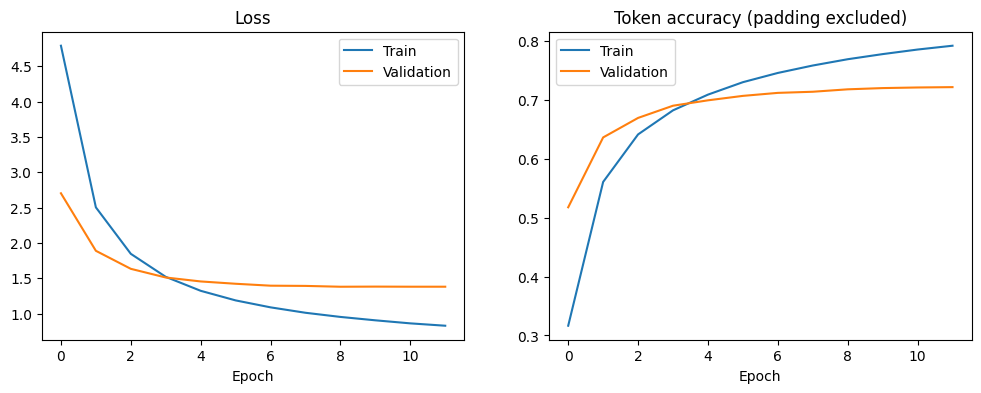

In [26]:
fig, (loss_ax, accuracy_ax) = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, title in [
    (loss_ax, "loss", "Loss"),
    (accuracy_ax, "masked_accuracy", "Token accuracy (padding excluded)"),
]:
    ax.plot(history.history[metric], label="Train")
    ax.plot(history.history[f"val_{metric}"], label="Validation")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()
plt.show()

Evaluate the final model on the held-out test set:

In [27]:
test_loss, test_masked_accuracy = transformer.evaluate(test_ds, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test token accuracy (padding excluded): {test_masked_accuracy:.4f}")

Test loss: 1.3837
Test token accuracy (padding excluded): 0.7141


## Decoding test sentences

Finally, let's demonstrate how to translate brand new English sentences.
We feed the vectorized English sentence into the encoder once, then repeatedly run the decoder,
starting from the token `"[start]"` and adding one generated token at a time until we hit `"[end]"`.
Sentences are decoded in batches.

With `beam_width=1` this is greedy decoding: take the most likely token at each step.
With a larger beam width, we keep the `beam_width` most likely partial translations at
each step and return the best finished one. Scores are length-normalized (GNMT-style,
`length_penalty` controls the strength), so beam search doesn't favor short translations.

In [28]:
spa_vocab = np.array(spa_vectorization.get_vocabulary())
start_token_id = int(np.where(spa_vocab == "[start]")[0][0])
end_token_id = int(np.where(spa_vocab == "[end]")[0][0])


def ids_to_text(token_ids):
    words = []
    for token_id in token_ids:
        if token_id in (0, end_token_id):
            break
        words.append(spa_vocab[token_id])
    return " ".join(words)


def translate(sentences, model=None, beam_width=1, length_penalty=0.6, batch_size=64):
    model = model or transformer
    encoder = model.get_layer("encoder")
    decoder = model.get_layer("decoder")
    output_projection = model.get_layer("output_projection")
    k = beam_width
    translations = []
    for start in range(0, len(sentences), batch_size):
        batch = list(sentences[start : start + batch_size])
        n = len(batch)
        source_ids = ops.convert_to_numpy(eng_vectorization(batch))
        encoded = ops.convert_to_numpy(encoder(source_ids, training=False))
        # Each sentence gets k beams, so repeat its encoding k times.
        encoder_inputs = {
            "encoder_outputs": np.repeat(encoded, k, axis=0),
            "encoder_padding_mask": np.repeat(source_ids != 0, k, axis=0),
        }

        sequences = np.zeros((n, k, sequence_length + 1), dtype="int64")
        sequences[:, :, 0] = start_token_id
        scores = np.full((n, k), -np.inf)
        scores[:, 0] = 0.0  # Start from a single live beam per sentence.
        finished = np.zeros((n, k), dtype=bool)
        rows = np.arange(n)[:, None]

        for i in range(sequence_length):
            hidden = decoder(
                {"decoder_inputs": sequences.reshape(n * k, -1)[:, :-1], **encoder_inputs},
                training=False,
            )
            probs = ops.convert_to_numpy(output_projection(hidden[:, i, :]))
            log_probs = np.log(np.maximum(probs, 1e-12)).reshape(n, k, -1)
            log_probs[..., 0] = -np.inf  # Never generate padding mid-sentence...
            log_probs[finished] = -np.inf  # ...but finished beams can only continue with
            log_probs[finished, 0] = 0.0  # padding, at no cost.

            candidates = (scores[:, :, None] + log_probs).reshape(n, -1)
            top = np.argpartition(-candidates, k - 1, axis=1)[:, :k]
            beam_ids, token_ids = np.divmod(top, log_probs.shape[-1])
            scores = candidates[rows, top]
            sequences = sequences[rows, beam_ids]
            sequences[:, :, i + 1] = token_ids
            finished = finished[rows, beam_ids] | (token_ids == end_token_id)
            if finished.all():
                break

        lengths = (sequences[:, :, 1:] != 0).sum(axis=-1)
        normalized_scores = scores / (((5.0 + lengths) / 6.0) ** length_penalty)
        best = normalized_scores.argmax(axis=1)
        translations.extend(ids_to_text(sequences[r, best[r], 1:]) for r in range(n))
    return translations

Some translations of test sentences (the model never saw these English sentences during
training), next to one of the dataset's reference translations:

In [29]:
def strip_markers(spa):
    return spa.removeprefix("[start] ").removesuffix(" [end]")


test_references = defaultdict(list)
for eng, spa in test_pairs:
    test_references[eng].append(strip_markers(spa))

sample_sources = random.Random(seed).sample(sorted(test_references), 20)
greedy_samples = translate(sample_sources)
beam_samples = translate(sample_sources, beam_width=beam_width)
for source, greedy, beam in zip(sample_sources, greedy_samples, beam_samples):
    print(source)
    print(f"  reference: {test_references[source][0]}")
    print(f"  greedy:    {greedy}")
    print(f"  beam:      {beam}")

There is no way of knowing where he's gone.
  reference: No hay manera de saber adónde él se ha ido.
  greedy:    no hay forma de saber dónde se ha ido
  beam:      no hay forma de saber dónde se ha ido
He caught her by the arm.
  reference: Él la cogió del brazo.
  greedy:    él la atrapó con el brazo
  beam:      él la atrapó con el brazo
At the funeral, the widow looked very dignified, with her black suit, hat and gloves.
  reference: En el funeral, la viuda lucía muy dignificada con su traje, sombrero, y guantes negros.
  greedy:    en el funeral en el funeral con el traje de [UNK] y el traje cien
  beam:      en el funeral del funeral se veía muy [UNK] con el traje y el traje
Tom is doing very well today.
  reference: Tom lo está haciendo muy bien hoy.
  greedy:    hoy tom está haciendo muy bien
  beam:      hoy tom está haciendo muy bien
I like ice cream.
  reference: Me gusta la nieve.
  greedy:    me gusta el helado
  beam:      me gusta el helado
I had no one to turn to.
  ref

## Measuring translation quality: BLEU and chrF

We score the model on test sentences with corpus-level
[BLEU](https://en.wikipedia.org/wiki/BLEU) and
[chrF](https://aclanthology.org/W15-3049/) (a character n-gram F-score that is more forgiving
of Spanish inflection), using `sacrebleu`. When the dataset has several Spanish translations of
the same English sentence, all of them are used as references.

The model only ever outputs lowercase text without punctuation, so the references are
normalized the same way before scoring. These scores are therefore not directly comparable to
published cased, punctuated BLEU scores. They are useful for comparing versions of this notebook.

In [30]:
def normalize(text):
    text = re.sub("[%s]" % re.escape(strip_chars), "", text.lower())
    return " ".join(text.split())


eval_sources = sorted(test_references)
random.Random(seed).shuffle(eval_sources)
eval_sources = eval_sources[:max_eval_sentences]
max_references = max(len(test_references[s]) for s in eval_sources)
# sacrebleu takes one stream per reference slot; None marks a sentence with fewer references.
reference_streams = [
    [
        normalize(test_references[s][i]) if i < len(test_references[s]) else None
        for s in eval_sources
    ]
    for i in range(max_references)
]

print(f"Scoring {len(eval_sources)} test sentences")
for name, width in [("greedy", 1), (f"beam (width {beam_width})", beam_width)]:
    hypotheses = translate(eval_sources, beam_width=width)
    bleu = sacrebleu.corpus_bleu(hypotheses, reference_streams)
    chrf = sacrebleu.corpus_chrf(hypotheses, reference_streams)
    print(f"{name:>16}: BLEU {bleu.score:5.1f}   chrF {chrf.score:5.1f}")

Scoring 3000 test sentences
          greedy: BLEU  38.1   chrF  60.9
  beam (width 4): BLEU  39.9   chrF  61.8


## Testing brand new sentences not in the original dataset

In [31]:
new_tests = [
    "I want to go to the library",
    "What is your name?",
    "How much does a beer cost?",
    "I want to fly to Japan tomorrow and go hiking",
]
for sentence, translated in zip(new_tests, translate(new_tests, beam_width=beam_width)):
    print(sentence)
    print(f"  {translated}")

I want to go to the library
  quiero ir a la biblioteca
What is your name?
  cómo se llama
How much does a beer cost?
  cuánto cuesta una cerveza
I want to fly to Japan tomorrow and go hiking
  quiero volar a japón y mañana iremos de [UNK]


## Saving and reloading

`ModelCheckpoint` already saved the best model to `artifacts/transformer.keras`. We also save
both vocabularies, because translating new text requires the exact same vectorization.
The cell below reloads everything and checks that the reloaded model translates identically.

In [32]:
for name, vectorization in [("eng", eng_vectorization), ("spa", spa_vectorization)]:
    (artifacts_dir / f"{name}_vocab.json").write_text(
        json.dumps(vectorization.get_vocabulary(), ensure_ascii=False), encoding="utf-8"
    )

restored_model = keras.saving.load_model(str(artifacts_dir / "transformer.keras"))
restored_spa_vectorization = TextVectorization(
    output_mode="int",
    output_sequence_length=sequence_length + 1,
    standardize=custom_standardization,
    vocabulary=json.loads((artifacts_dir / "spa_vocab.json").read_text(encoding="utf-8")),
)
restored_eng_vocab = json.loads((artifacts_dir / "eng_vocab.json").read_text(encoding="utf-8"))
assert restored_eng_vocab == eng_vectorization.get_vocabulary()
assert restored_spa_vectorization.get_vocabulary() == spa_vectorization.get_vocabulary()
assert translate(new_tests, model=restored_model) == translate(new_tests)
print("Reloaded model and vocabulary match.")

Reloaded model and vocabulary match.
